In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from imblearn.over_sampling import SMOTE
import optuna
import matplotlib.pyplot as plt

In [3]:
# Load the dataset
df = pd.read_csv(r'C:\Users\khiew\Downloads\FYP Augmented (Secondly) Dataset.csv')

In [ ]:
# Drop diseases with less than 750 instances
disease_counts = df['diseases'].value_counts()
valid_diseases = disease_counts[disease_counts >= 750].index
df = df[df['diseases'].isin(valid_diseases)]

# Assuming that the target variable is 'diseases' and all other variables are input features
X = df.drop('diseases', axis=1)
y = df['diseases']

# Encode the target variable (diseases) if it's a categorical variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
num_classes = len(np.unique(y_train))
input_dim = X_train.shape[1]
print("Number of remaining classes in training set:", len(np.unique(y_train)))
print("Number of rows left:", len(df))

Number of remaining classes in training set: 114
Number of rows left: 114312


In [5]:
# Apply SMOTE for class balancing in the training set
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Print the new class distribution after SMOTE
print("Class distribution after SMOTE:")
print(pd.Series(y_train_resampled).value_counts())
print("Number of remaining classes in training set:", len(np.unique(y_train_resampled)))
# Print the number of rows in the resampled training set
print("Number of rows in the resampled training set:", len(X_train_resampled))

Class distribution after SMOTE:
20     1002
9      1002
66     1002
80     1002
1      1002
       ... 
40     1002
106    1002
54     1002
102    1002
88     1002
Name: count, Length: 114, dtype: int64
Number of remaining classes in training set: 114
Number of rows in the resampled training set: 114228


In [6]:
# Apply SMOTE for class balancing in the training set
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Print the new class distribution after SMOTE
print("Class distribution after SMOTE:")
print(pd.Series(y_train_resampled).value_counts())
print("Number of remaining classes in training set:", len(np.unique(y_train_resampled)))
# Print the number of rows in the resampled training set
print("Number of rows in the resampled training set:", len(X_train_resampled))

Class distribution after SMOTE:
20     1002
9      1002
66     1002
80     1002
1      1002
       ... 
40     1002
106    1002
54     1002
102    1002
88     1002
Name: count, Length: 114, dtype: int64
Number of remaining classes in training set: 114
Number of rows in the resampled training set: 114228


In [7]:
# Optuna objective function
def objective(trial):
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    # Suggest hyperparameters
    n_layers = trial.suggest_int('n_layers', 1, 3)
    for i in range(n_layers):
        num_units = trial.suggest_int(f'n_units_{i}', 64, 256, step=64)
        activation = trial.suggest_categorical(f'activation_{i}', ['relu', 'tanh'])
        model.add(layers.Dense(num_units, activation=activation))
        dropout_rate = trial.suggest_float(f'dropout_rate_{i}', 0.2, 0.5)
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(num_classes, activation='softmax'))

    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(X_train_resampled, y_train_resampled,
                        validation_split=0.2,
                        epochs=10,
                        batch_size=trial.suggest_categorical('batch_size', [32, 64, 128]),
                        verbose=0)

    val_accuracy = max(history.history['val_accuracy'])
    return val_accuracy

In [9]:
# Create Optuna study for optimization with persistent storage
study = optuna.create_study(
    direction='maximize',  # Assuming you are maximizing accuracy
    study_name="DNN_diseases_symptoms_dropextremelymore750withSMOTE_secondaugmented_study", 
    storage=r"sqlite:///C:/Users/khiew/Downloads/dnn.db", 
    load_if_exists=True  # Load the study if it already exists, to resume from the last trial
)

# Optimize the study with your objective function, you can adjust the n_trials as needed
study.optimize(objective, n_trials=20)
# Print the best trial and hyperparameters
print("\nBest Trial:")
print(study.best_trial)
print("Best Hyperparameters:")
print(study.best_trial.params)

[I 2025-04-25 01:29:04,654] Using an existing study with name 'DNN_diseases_symptoms_dropextremelymore750withSMOTE_secondaugmented_study' instead of creating a new one.
[I 2025-04-25 01:30:09,100] Trial 7 finished with value: 0.6780617833137512 and parameters: {'n_layers': 2, 'n_units_0': 192, 'activation_0': 'relu', 'dropout_rate_0': 0.2038964495245399, 'n_units_1': 64, 'activation_1': 'tanh', 'dropout_rate_1': 0.4388557651883983, 'learning_rate': 0.0002362280877467302, 'batch_size': 32}. Best is trial 7 with value: 0.6780617833137512.
[I 2025-04-25 01:31:16,430] Trial 8 finished with value: 0.6806005239486694 and parameters: {'n_layers': 3, 'n_units_0': 256, 'activation_0': 'tanh', 'dropout_rate_0': 0.24950448918312634, 'n_units_1': 64, 'activation_1': 'tanh', 'dropout_rate_1': 0.23277565410249001, 'n_units_2': 192, 'activation_2': 'tanh', 'dropout_rate_2': 0.3078610874873298, 'learning_rate': 0.00024718525973667214, 'batch_size': 32}. Best is trial 8 with value: 0.6806005239486694.



Best Trial:
FrozenTrial(number=12, state=TrialState.COMPLETE, values=[0.6841460466384888], datetime_start=datetime.datetime(2025, 4, 25, 1, 33, 16, 296005), datetime_complete=datetime.datetime(2025, 4, 25, 1, 33, 43, 903645), params={'n_layers': 1, 'n_units_0': 64, 'activation_0': 'tanh', 'dropout_rate_0': 0.22095463003311197, 'learning_rate': 0.000455511404499834, 'batch_size': 64}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_layers': IntDistribution(high=3, log=False, low=1, step=1), 'n_units_0': IntDistribution(high=256, log=False, low=64, step=64), 'activation_0': CategoricalDistribution(choices=('relu', 'tanh')), 'dropout_rate_0': FloatDistribution(high=0.5, log=False, low=0.2, step=None), 'learning_rate': FloatDistribution(high=0.01, log=True, low=0.0001, step=None), 'batch_size': CategoricalDistribution(choices=(32, 64, 128))}, trial_id=33, value=None)
Best Hyperparameters:
{'n_layers': 1, 'n_units_0': 64, 'activation_0': 'tanh', 'dropout_rate_0': 

Epoch 1/20
1428/1428 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.2850 - loss: 3.6913 - val_accuracy: 0.6013 - val_loss: 1.6175
Epoch 2/20
1428/1428 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6441 - loss: 1.3439 - val_accuracy: 0.6420 - val_loss: 1.1475
Epoch 3/20
1428/1428 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6742 - loss: 1.0301 - val_accuracy: 0.6615 - val_loss: 1.0165
Epoch 4/20
1428/1428 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6806 - loss: 0.9364 - val_accuracy: 0.6718 - val_loss: 0.9550
Epoch 5/20
1428/1428 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6884 - loss: 0.8863 - val_accuracy: 0.6754 - val_loss: 0.9224
Epoch 6/20
1428/1428 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6875 - loss: 0.8661 - val_accuracy: 0.6769 - val_loss: 0.9080
Epoch 7/20
1428/1428 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6912 - loss: 0.8479 - val_accuracy: 0.6789 - val_loss: 0.8974
Epoch 8/20
1428/1428 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6926 - loss: 0.8400 - 

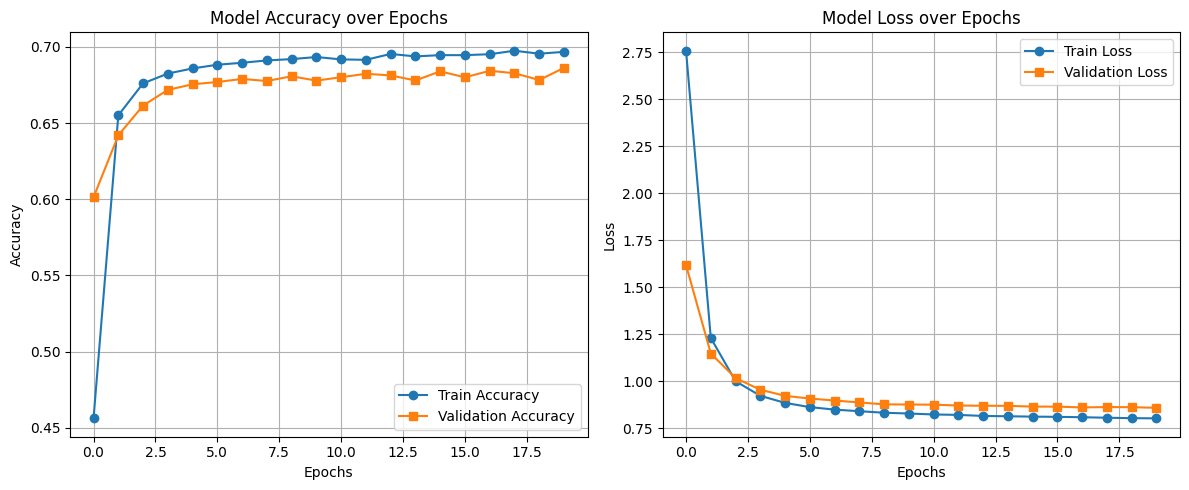

In [10]:
# Load Optuna study
study = optuna.load_study(
    study_name="DNN_diseases_symptoms_dropextremelymore750withSMOTE_secondaugmented_study",
    storage="sqlite:///C:/Users/khiew/Downloads/dnn.db"
)

# Get best parameters
best_params = study.best_trial.params

# Rebuild model using best parameters
best_model = keras.Sequential()
best_model.add(layers.Input(shape=(input_dim,)))

for i in range(best_params['n_layers']):
    best_model.add(layers.Dense(best_params[f'n_units_{i}'], activation=best_params[f'activation_{i}']))
    best_model.add(layers.Dropout(best_params[f'dropout_rate_{i}']))

best_model.add(layers.Dense(num_classes, activation='softmax'))

best_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Fit the model and save training history
history = best_model.fit(
    X_train_resampled,
    y_train_resampled,
    epochs=20,
    batch_size=best_params['batch_size'],
    validation_split=0.2,
    verbose=1
)

# ===========================
# Plotting Training Lifecycle
# ===========================

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='s')
plt.title('Model Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [11]:
from sklearn.metrics import classification_report

y_pred_test = np.argmax(best_model.predict(X_test), axis=1)
print("Classification Report on Test Set:")
print(classification_report(y_test, y_pred_test, target_names=label_encoder.classes_))


715/715 ━━━━━━━━━━━━━━━━━━━━ 0s 595us/step
Classification Report on Test Set:
                                              precision    recall  f1-score   support

                           actinic keratosis       0.26      0.61      0.37       192
                         acute bronchiolitis       0.74      0.78      0.76       245
                            acute bronchitis       0.69      0.59      0.64       275
                          acute bronchospasm       0.75      0.57      0.65       174
                         acute kidney injury       0.97      0.91      0.94       202
                          acute pancreatitis       1.00      0.74      0.85       245
                             acute sinusitis       0.63      0.53      0.57       188
                       acute stress reaction       1.00      0.81      0.90       158
                                     allergy       0.95      0.72      0.82       175
                                      angina       0.68      

c:\Users\khiew\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\khiew\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\khiew\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo